## Imports

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report, f1_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import graphviz
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

seed = 100

In [23]:
sheet_id = "1JXglxzN5O5KaE-KHNj4Ni_vrTpG3gxGLEJLVieUI8ks"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

df = pd.read_csv(url)
# fix fake missing values (things that say None, but aren't missing)
df['Item'] = df['Item'].fillna('None')
df['Exhaustion Perk'] = df['Exhaustion Perk'].fillna('None')
df.head()

,Survivor Gender,Steam Player,Anonymous Mode,Prestige,Item,Powerful Add-ons,Exhaustion Perk,Chase Perks,Decisive Strike,Unbreakable,Off the Record,Adrenaline,Map Type,Map Area,Survivor BP,Killer BP,Result
0,M,No,No,26,Medkit,No,None,0,No,No,No,No,Outdoor,9984,21706,25250,Escape
1,M,No,No,11,Medkit,No,Sprint Burst,0,No,No,No,No,Outdoor,9984,16049,25250,Dead
2,F,No,No,11,Toolbox,No,Dead Hard,1,No,No,No,No,Outdoor,9984,15402,25250,Dead
3,F,No,No,5,Toolbox,No,Lithe,0,No,Yes,No,Yes,Outdoor,9984,7048,25250,Dead
4,F,Yes,No,54,Toolbox,No,Sprint Burst,0,No,No,No,No,Outdoor,9984,15996,25700,Dead


# Data Dictionary

Survivor Gender - categorical, binary, indicates gender of character being played (M/F)

Steam Player - categorical, binary, indicates if they're playing on Steam or not (not includes console and Epic Games), (Yes/No)

Anonymous Mode - categorical, binary, whether or not they have anonymous mode enabled (Yes/No)

Prestige - numeric, integer, what prestige their character is, can indicate level of experience in terms of time put into the game (0-100)

Item - cateogrical, what item they brought (Medkit, Flashlight, Toolbox, etc.), other items that aren't medkits, flashlights, or toolboxes should likely be grouped together into "Other" (excluding None)

Powerful Add-ons - categorical, binary, whether or not they brought powerful add-ons with their brought item (Yes/No)

Exhaustion Perk - categorical, indicates which exhaustion perk they brought, this is a type of perk that is quite strong and provides a large advantage (Dead Hard, Lithe, Sprint Burst, etc.), anything other than those three should likely be grouped into "Other" (excluding None)

Chase Perks - numeric, integer, indicates how many chase-related perks they brought (0-3), includes resilience, finesse, and windows of opportunity

Decisive Strike - categorical, binary, strong second chance perk that can be game changer

Unbreakable - categorical, binary, strong second chance perk that can be game changer

Off the Record - categorical, binary, strong second chance perk that can be game changer

Adrenaline - categorical, binary, strong second chance perk that can be game changer

Map Type - categorical, binary, type of map the match is played on (Indoor/Outdoor)

Map Area - numeric, integer, area in meters squared the map is

Survivor BP - numeric, integer, indicates how many bloodpoints (points) that survivor gained from that match, which are accumulated from things like performing well and being efficient over the course of the game

Killer BP - numeric, integer, indicates how many bloodpoints (points) the killer (me) gained from that match, which are accumulated from things like performing well and outplaying the opposition consistently

Result - categorical, binary, outcome the survivor reached from that given match (Escaped/Dead)

# Questions and Background Information

Question - Can you predict the result of a player's match based on characteristics like the character they play, the prestige level they are, and what item they bring?

This dataset is custom-made by Nathaniel, and has been pre-cleaned for the most part, but some changes can easily be made for it to be ready for logistic regression and other model types. The data is scraped from a few hundred matches of the game Dead by Daylight, which is an asymmetrical horror game, and the data has been screenshotted from the results screen and then extracted to a spreadsheet. It includes things like what item the survivor brought, what prestige they are, certain perks they brought, and their match outcome (result).

This question is interesting because it allows us to analyze outcomes in a video game setting, basing our decisions on visible characteristics, most of which are visible before even loading into the match. This means you could also use a model like this to determine before loading into a match how likely it is that you get a good or bad result. It also can be used to interpret what areas of the game might need to be targeted for balancing changes, or what changes a player might need to make in their own gameplay and such. Making these predictions is also a good balance of engaging with a passion as well as learning more about the gameplay and inner workings of the system itself.

This type of model also can be applied to applications like NightLight where people are submitting their data frequently, but sometimes there are missing fields, especially escape versus dead due to cropping issues, or leaving matches early. So making a consistent model for things like this could be a good indicator for this type of prediction and inference. Considering this perspective is very important as it is most similar to what we may end up doing in the field of data scientists as a full-time career as we are making predictions, trying to figure out missing data, build models off existing data, etc.

# Exploratory Data Analysis

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Survivor Gender   680 non-null    str  
 1   Steam Player      680 non-null    str  
 2   Anonymous Mode    680 non-null    str  
 3   Prestige          680 non-null    int64
 4   Item              680 non-null    str  
 5   Powerful Add-ons  680 non-null    str  
 6   Exhaustion Perk   680 non-null    str  
 7   Chase Perks       680 non-null    int64
 8   Decisive Strike   680 non-null    str  
 9   Unbreakable       680 non-null    str  
 10  Off the Record    680 non-null    str  
 11  Adrenaline        680 non-null    str  
 12  Map Type          680 non-null    str  
 13  Map Area          680 non-null    int64
 14  Survivor BP       680 non-null    int64
 15  Killer BP         680 non-null    int64
 16  Result            680 non-null    str  
dtypes: int64(5), str(12)
memory usage: 90.4 KB


Our dataset has 680 rows with 17 columns and no missing values. There were some issues as the dataset has the word "None" as a real category for things like item brought, which gets detected as missing because it counts as None, but this was replaced above using fillna. We have a decent mix of 5 numeric and 12 categorical variables, so we will have to do a bit of preprocessing in different ways.

In [25]:
df = df.drop(columns=['Powerful Add-ons', 'Decisive Strike', 'Unbreakable', 'Off the Record', 'Adrenaline', 'Map Area'])

# limit the amount of
df['Item'] = df['Item'].apply(lambda x: x if x in ['Medkit', 'Flashlight', 'Toolbox', 'None'] else 'Other')
df['Exhaustion Perk'] = df['Exhaustion Perk'].apply(lambda x: x if x in ['Dead Hard', 'Lithe', 'Sprint Burst', 'None'] else 'Other')

df

,Survivor Gender,Steam Player,Anonymous Mode,Prestige,Item,Exhaustion Perk,Chase Perks,Map Type,Survivor BP,Killer BP,Result
0,M,No,No,26,Medkit,None,0,Outdoor,21706,25250,Escape
1,M,No,No,11,Medkit,Sprint Burst,0,Outdoor,16049,25250,Dead
2,F,No,No,11,Toolbox,Dead Hard,1,Outdoor,15402,25250,Dead
3,F,No,No,5,Toolbox,Lithe,0,Outdoor,7048,25250,Dead
4,F,Yes,No,54,Toolbox,Sprint Burst,0,Outdoor,15996,25700,Dead
...,...,...,...,...,...,...,...,...,...,...,...
675,F,No,No,34,Toolbox,None,0,Outdoor,11110,27496,Dead
676,F,No,No,39,Toolbox,Sprint Burst,0,Outdoor,21557,30647,Dead
677,M,Yes,No,81,Toolbox,Other,0,Outdoor,21314,30647,Dead
678,F,Yes,No,23,Flashlight,Other,0,Outdoor,20337,30647,Dead


We drop these columns as they are either very imbalanced or too hyperspecific for the given model context or correlated to other variables in the dataset (map area is correlated with map type somewhat). Item and exhaustion perk are also grouped so that it doesn't need to include all the individual variables and instead keeps the top 3 as well as a lack thereof, and replaces the other entries that are less popular with "Other" to prevent unnecessary complexity.

<Axes: >

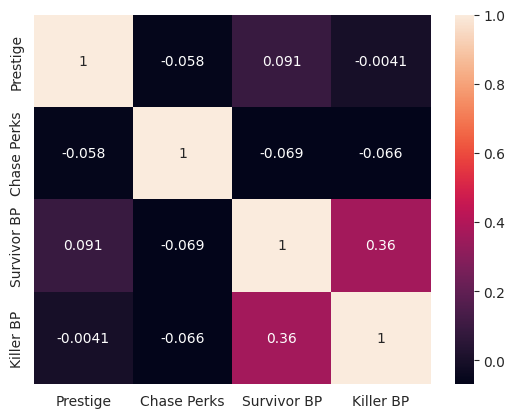

In [26]:
sns.heatmap(df.corr(numeric_only = True), annot=True)

There appear to be not many significant relationships in terms of correlation with the sole exception of the two points categories which makes sense to a degree when considering things like skill-based matchmaking and such. Higher skilled survivors will get put up against higher skilled killers, often leading to both sides scoring more or less points together to some extent.

In [27]:
prevalence = (df['Result'] == 'Escape').mean()
print(f'Overall escape rate in dataset: {prevalence * 100}%')

Overall escape rate in dataset: 15.0%


Since this is quite imbalanced, we will address this in making the model by adding balanced class weight in the modeling itself through the argument being set to class_weight = 'balanced' (but we will at first test models without it).

We want to check for distributions of the variables to see if anything stands out or may need to be removed, so we graph each one below.

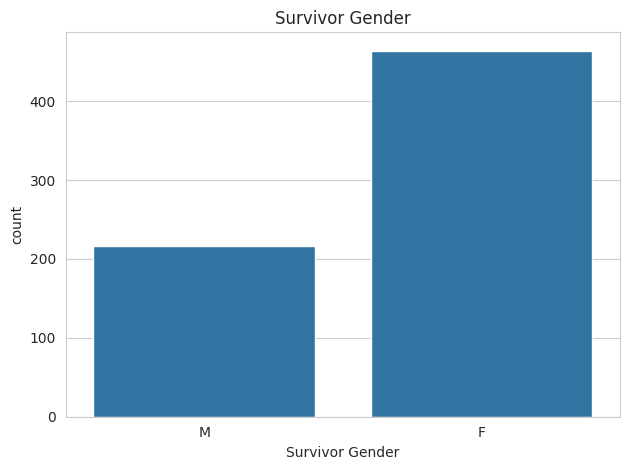

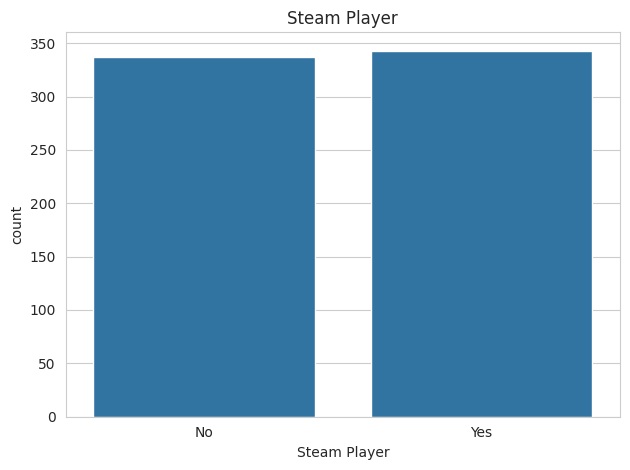

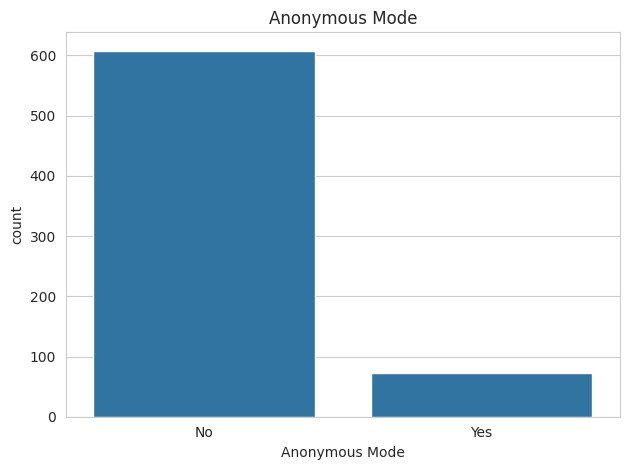

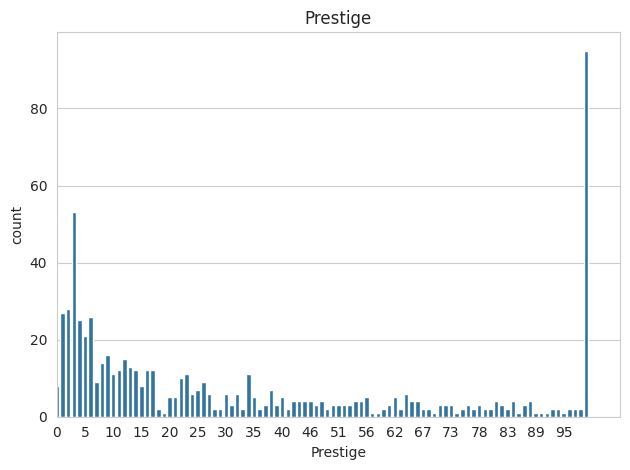

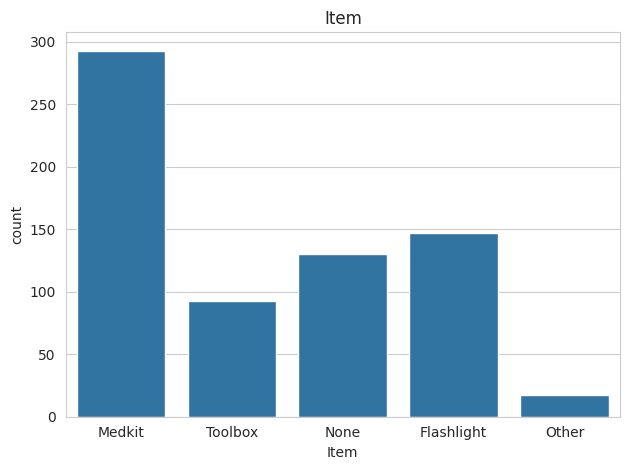

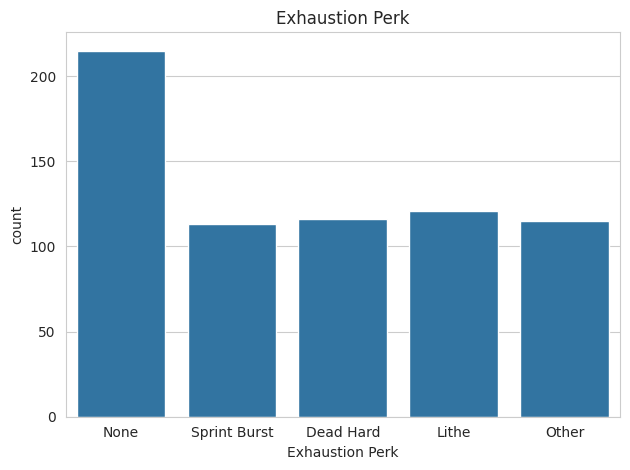

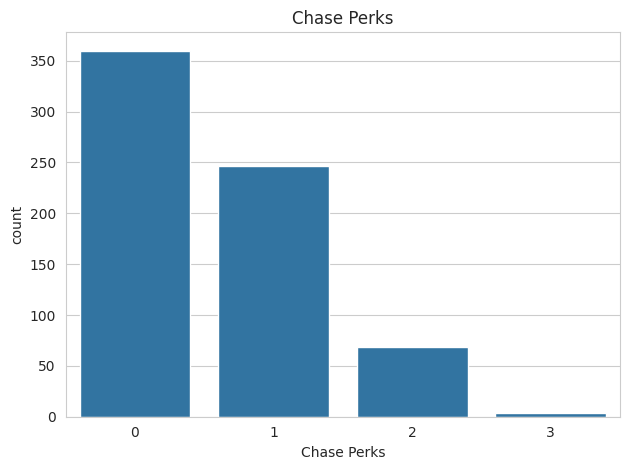

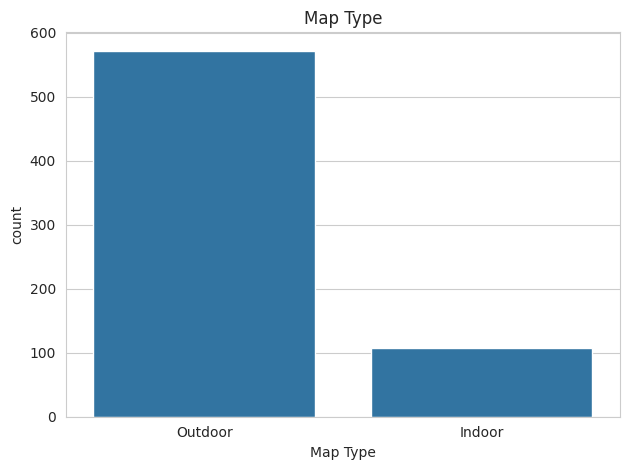

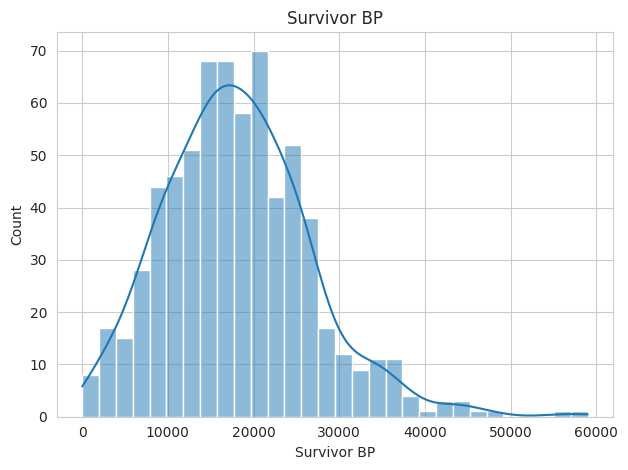

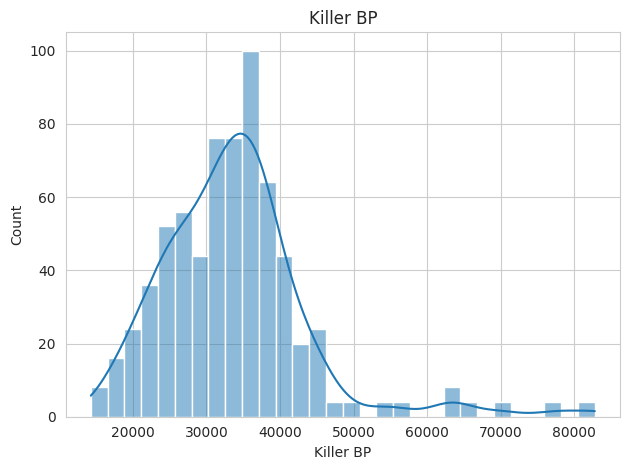

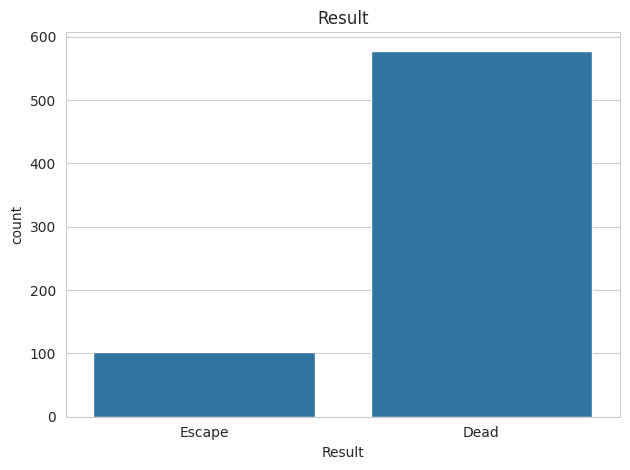

In [28]:
# More EDA (make some graphs of variables)

for each in df.columns: # NEW plot each time
    plt.figure()
    if each in ['Survivor BP', 'Killer BP']: # these graphs need to look different due to many many unique values
      sns.histplot(x = df[each], bins = 30, kde = True)
    else:
      sns.countplot(x=df[each])
    plt.title(each)
    if each == "Prestige":
        plt.xlim(0, 100)
        plt.xticks(np.arange(0, 100, step=5))
    plt.tight_layout()
    plt.show()

There is an imbalance in the result category as previously mentioned, but there are also some interesting imbalances in things like survivor gender and item brought. The distributions of things like prestige and points make sense to be skewed as there will be higher quantities of players with either maximized prestige (100) as well as some skew in terms of points as there will be outliers for this.

In [29]:
df[df.select_dtypes(include='number').columns.tolist()].describe()

,Prestige,Chase Perks,Survivor BP,Killer BP
count,680.000000,680.000000,680.000000,680.000000
mean,36.270588,0.583824,18132.279412,33774.211765
std,35.427459,0.694203,8592.890614,10249.912900
min,0.000000,0.000000,0.000000,14290.000000
25%,6.000000,0.000000,12143.500000,27118.000000
50%,22.000000,0.000000,17595.000000,33143.500000
75%,64.000000,1.000000,23210.750000,38088.000000
max,100.000000,3.000000,59008.000000,82768.000000


# Methods

## Model 1 (Logistic Regression, single model)

In [30]:
# set apart different feature types for preprocessing
num_features = df.select_dtypes(include='number').columns.tolist()
cat_features = df.select_dtypes(include='object').columns.tolist()
cat_features = [col for col in cat_features if col != 'Result']
target = 'Result'

print(num_features)
print(cat_features)

['Prestige', 'Chase Perks', 'Survivor BP', 'Killer BP']
['Survivor Gender', 'Steam Player', 'Anonymous Mode', 'Item', 'Exhaustion Perk', 'Map Type']


In [31]:
# Set X and y for modeling

X = df[cat_features + num_features]
y = (df[target] == 'Escape').astype(int)

# Split dataset into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = seed, stratify = y)
print(f'Train size: {X_train.shape}')
print(f'Test size: {X_test.shape}')

Train size: (544, 10)
Test size: (136, 10)


In [32]:
# Model 1

preprocess1 = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), cat_features),
    ('num', MinMaxScaler(), num_features)
])

pipe_logistic1 = Pipeline(steps = [
    ('prep', preprocess1),
    ('model', LogisticRegression(solver = 'lbfgs', max_iter = 1000, random_state = seed))
])

pipe_logistic1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

# Evaluation of Model 1 (Logistic Regression, single model)

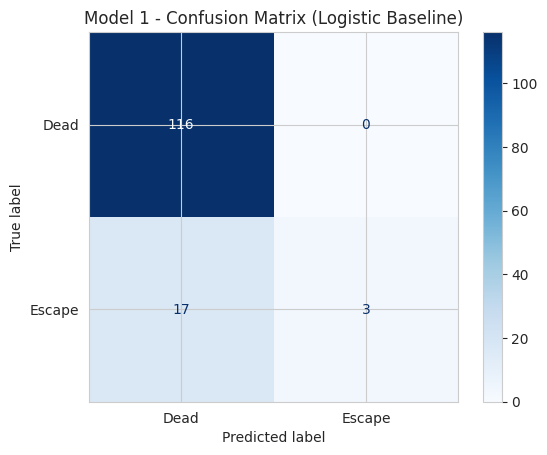

              precision    recall  f1-score   support

        Dead       0.87      1.00      0.93       116
      Escape       1.00      0.15      0.26        20

    accuracy                           0.88       136
   macro avg       0.94      0.57      0.60       136
weighted avg       0.89      0.88      0.83       136



In [33]:
# Confusion matrix
y_pred1 = pipe_logistic1.predict(X_test)
y_proba_m1 = pipe_logistic1.predict_proba(X_test)[:, 1]

cm1 = confusion_matrix(y_test, y_pred1)
ConfusionMatrixDisplay(cm1, display_labels = ['Dead', 'Escape']).plot(cmap = 'Blues')
plt.title('Model 1 - Confusion Matrix (Logistic Baseline)')
plt.show()

print(classification_report(y_test, y_pred1, target_names = ['Dead', 'Escape']))

This confusion matrix makes the issue very apparent that the model is basically just guessing dead for most of them due to the imbalance in the results. The "accuracy" here being high doesn't actually mean much because it's not an actual meaninful metric for measuring this dataset, which is exactly why accuracy can be a misleading metric depending on the data.

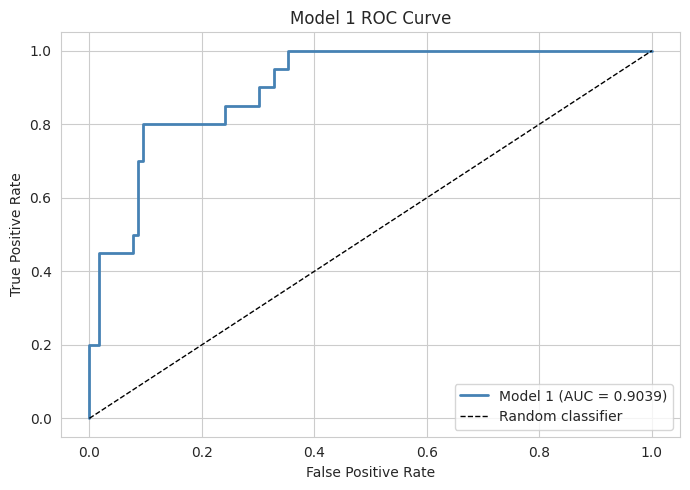

Model 1 ROC-AUC: 0.9038793103448276


In [34]:
# Create ROC-AUC curve
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m1)
auc_m1 = roc_auc_score(y_test, y_proba_m1)

fig, ax = plt.subplots(figsize = (7, 5))
ax.plot(fpr_m1, tpr_m1, lw = 2, color = 'steelblue', label = f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw = 1, label = 'Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc = 'lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc_m1}")

The AUC score is somewhat high as well, but again the issue lies within the imbalance of data and looking at the other metrics tells us the story that there are some severe issues within this first model that need to be addressed (mainly the imbalance and the dataset size).

# Data Tuning Changes

In [35]:
best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0, 1, 0.01):
    y_pred1_t = (y_proba_m1 >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred1_t, zero_division = 0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f'Best threshold: {best_threshold}')
print(f'Best F1: {best_f1}')

Best threshold: 0.2
Best F1: 0.6530612244897959


This shows that the threshold is best set at 0.2, which makes sense because our imbalance was very blatant and a big issue when it was at 0.5. The best F1 is achieved at 0.2 threshold.

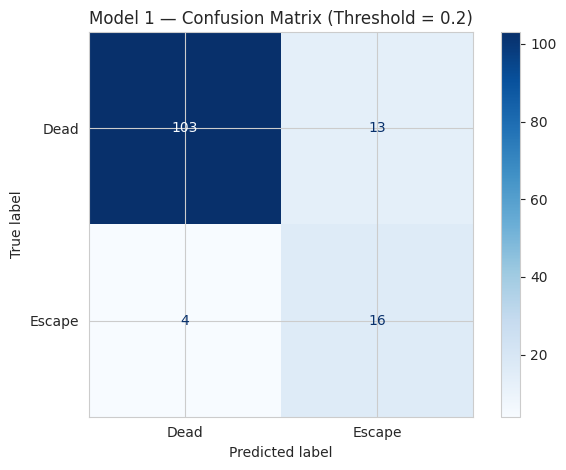

              precision    recall  f1-score   support

        Dead       0.96      0.89      0.92       116
      Escape       0.55      0.80      0.65        20

    accuracy                           0.88       136
   macro avg       0.76      0.84      0.79       136
weighted avg       0.90      0.88      0.88       136



In [36]:
threshold = 0.2 # decrease threshold to address class imbalance of target
y_pred1_t = (y_proba_m1 >= threshold).astype(int)

cm_t = confusion_matrix(y_test, y_pred1_t)
ConfusionMatrixDisplay(cm_t, display_labels=['Dead', 'Escape']).plot(cmap='Blues')
plt.title(f'Model 1 — Confusion Matrix (Threshold = {threshold})')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred1_t, target_names = ['Dead', 'Escape']))

This shows large improvements compared to before and actually makes an effort to predict the escape class, so we will keep the threshold of 0.2 moving forward into the next model. The recall of the escaped class jumped up to 0.80, which is MUCH better than before. Precision drops a bit, but this tradeoff is very worthwhile, but will still be improved upon in the next model. These changes will move forward into model 2.

## Model 2 (Balanced Logistic Regression and Cross-Validation)

In [37]:
# Model 2 (adjusted logistic regression with cross-validation)

preprocess2 = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), cat_features),
    ('num', MinMaxScaler(), num_features)
])

pipe_logistic2 = Pipeline(steps = [
    ('prep', preprocess2),
    ('model', LogisticRegression(solver = 'liblinear', max_iter = 1000, random_state = seed, class_weight = 'balanced')) # change solver to liblinear for smaller dataset
])

pipe_logistic2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [38]:
# Cross Validation
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = seed)
cv_auc = cross_val_score(pipe_logistic2, X_train, y_train, cv = cv, scoring = 'roc_auc')
cv_f1 = cross_val_score(pipe_logistic2, X_train, y_train, cv = cv, scoring = 'f1')

print(f'Cross-Validation AUC Mean: {cv_auc.mean()}')
print(f'Cross-Validation AUC Standard Deviation: {cv_auc.std()}')
print(f'Cross-Validation F1: {cv_f1.mean()}')

Cross-Validation AUC Mean: 0.8908737934163848
Cross-Validation AUC Standard Deviation: 0.006312228157784088
Cross-Validation F1: 0.5731582432261911


The cv AUC being centered around 0.89 and quite tightly distributed confirms that this model generalizes much more consistently than the prior model did rather than just getting lucky in a particular split, which importantly provides evidence that it's not becoming overfit on the data.

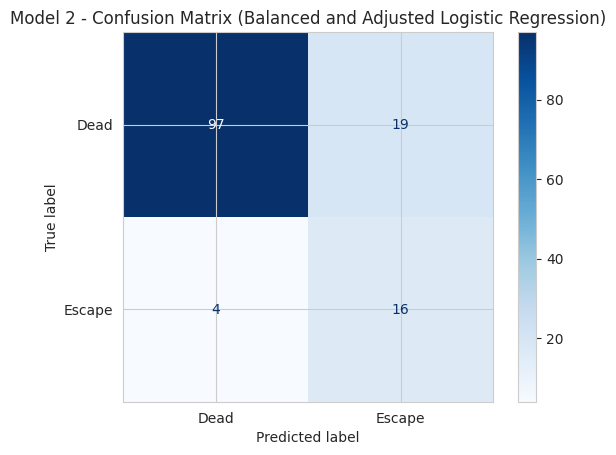

              precision    recall  f1-score   support

        Dead       0.96      0.84      0.89       116
     Escaped       0.46      0.80      0.58        20

    accuracy                           0.83       136
   macro avg       0.71      0.82      0.74       136
weighted avg       0.89      0.83      0.85       136



In [39]:
# Confusion Matrix 2
y_pred2 = pipe_logistic2.predict(X_test)
y_proba_m2 = pipe_logistic2.predict_proba(X_test)[:, 1]

cm2 = confusion_matrix(y_test, y_pred2)
ConfusionMatrixDisplay(cm2, display_labels = ['Dead', 'Escape']).plot(cmap = 'Blues')
plt.title('Model 2 - Confusion Matrix (Balanced and Adjusted Logistic Regression)')
plt.show()

print(classification_report(y_test, y_pred2, target_names=['Dead', 'Escaped']))

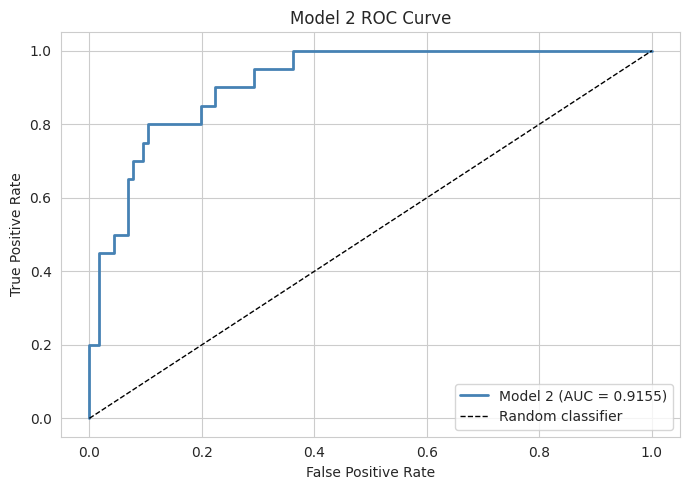

Model 2 ROC-AUC: 0.9155172413793105


In [40]:
fpr_m2, tpr_m2, thresholds_m2 = roc_curve(y_test, y_proba_m2)
auc_m2 = roc_auc_score(y_test, y_proba_m2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m2, tpr_m2, lw=2, color='steelblue', label=f'Model 2 (AUC = {auc_m2:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'Model 2 ROC-AUC: {auc_m2}')

The AUC curve improved from model 1, even after being balanced properly, so this result should actually be reflecting a good set of changes and results from our new model. This also confirms that the balancing of the result class is more than just redistrbuting weights, it actually does help improve the model and its ability to discern between the results, making it our best model so far (not that it had much competition with that first one).

## Model 3 (Decision Tree)


In [41]:
preprocess3 = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), cat_features),
    ('num', MinMaxScaler(), num_features)
])

pipe_decisiontree = Pipeline(steps = [
    ('prep', preprocess3),
    ('model', DecisionTreeClassifier(class_weight = 'balanced', max_depth = 5, min_samples_leaf = 20, random_state = seed))
])

pipe_decisiontree.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

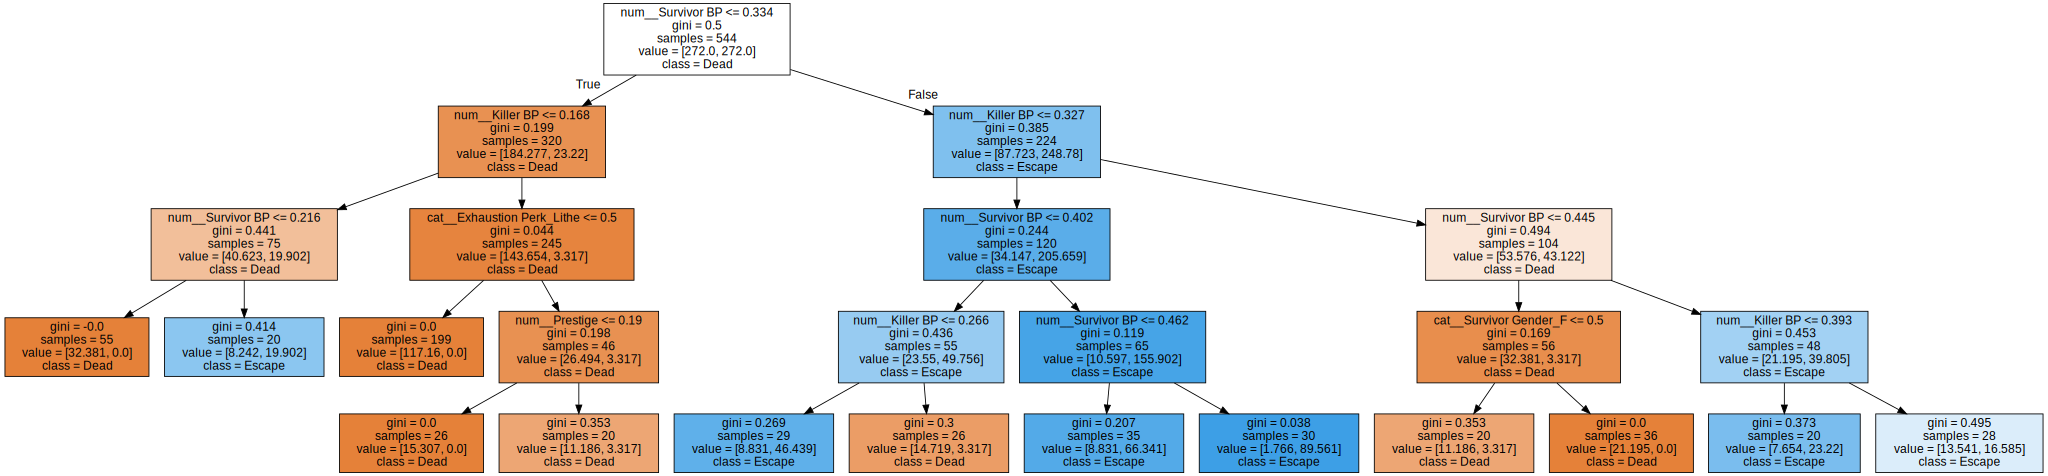

In [ ]:
# Decision Tree Chart
feature_names = pipe_decisiontree['prep'].get_feature_names_out()
tree_chart = export_graphviz(pipe_decisiontree['model'], feature_names = feature_names, class_names = ['Dead', 'Escape'], filled = True, out_file = None)
tree_graph = graphviz.Source(tree_chart)
tree_graph.render('decision_tree') # MAKE SURE TO INSTALL GRAPHVIZ APP FOR THIS TO WORK -- (sudo apt-get update && sudo apt-get install graphviz)
tree_graph


The primary splits in this tree rely on the points categories, which makes sense as that can also indicate the opposition's skill level and experience.  From there, it relies on a couple things like specific perks used or the surivor's gender the person picked, as these may be indicative of certain playstyles or experience differences. We kept the decisions max at 4-5 to prevent it from growing too specifically on the training data, which is especially important on smaller datasets like these.

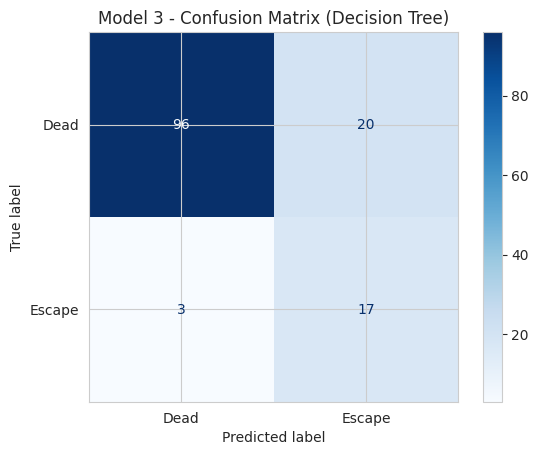

              precision    recall  f1-score   support

        Dead       0.97      0.83      0.89       116
      Escape       0.46      0.85      0.60        20

    accuracy                           0.83       136
   macro avg       0.71      0.84      0.74       136
weighted avg       0.89      0.83      0.85       136

Test Set AUC: 0.8968


In [43]:
# Confusion Matrix

y_pred3 = pipe_decisiontree.predict(X_test)
y_proba_m3 = pipe_decisiontree.predict_proba(X_test)[:, 1]

cm3 = confusion_matrix(y_test, y_pred3)
ConfusionMatrixDisplay(cm3, display_labels = ['Dead', 'Escape']).plot(cmap = 'Blues')
plt.title('Model 3 - Confusion Matrix (Decision Tree)')
plt.show()

print(classification_report(y_test, y_pred3, target_names = ['Dead', 'Escape']))
print(f'Test Set AUC: {roc_auc_score(y_test, y_proba_m3):.4f}')

This model achieves a similar confusion matrix to the second model of logistic regression, but with slightly lower precision scores.

In [44]:
# Cross validation

cv_auc_decisiontree = cross_val_score(pipe_decisiontree, X_train, y_train, cv = cv, scoring = 'roc_auc')
cv_f1_decisiontree = cross_val_score(pipe_decisiontree, X_train, y_train, cv = cv, scoring = 'f1')

print(f'Cross-validation AUC Mean: {cv_auc_decisiontree.mean()}')
print(f'Cross-validation AUC Standard Deviation: {cv_auc_decisiontree.std()}')
print(f'Cross-validation F1: {cv_f1_decisiontree.mean()}')

Cross-validation AUC Mean: 0.8802597248576852
Cross-validation AUC Standard Deviation: 0.03278801959174574
Cross-validation F1: 0.591377969952283


The cross-validation scores show a high mean with a somewhat tightly distributed distribution, but it's more spread out than model 2, and pairing this with the lower precision scores from the confusion matrix and metrics above, we can likely assume that model 2 is better to some degree.

In [45]:
# Grid Search CV
# create new pipeline for gridsearch
preprocess_gs = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), cat_features),
    ('num', MinMaxScaler(), num_features)
])

pipe_gs = Pipeline(steps = [
    ('prep', preprocess_gs),
    ('model', DecisionTreeClassifier(class_weight = 'balanced', random_state = seed))
])

param_grid = {'model__max_depth': [2, 3, 4, 5, 6, 8, 10, 15, None],
              'model__min_samples_leaf': [5, 10, 20]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
grid_search = GridSearchCV(pipe_gs, param_grid, cv=cv, scoring='roc_auc')
grid_search.fit(X_train, y_train)

# Results
print(f"Best Depth: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

pd.DataFrame({
    'Max Depth': grid_search.cv_results_['param_model__max_depth'],
    'Min Samples Leaf': grid_search.cv_results_['param_model__min_samples_leaf'],
    'Mean AUC': grid_search.cv_results_['mean_test_score']
})



Best Depth: {'model__max_depth': 4, 'model__min_samples_leaf': 20}
Best CV AUC: 0.8803


,Max Depth,Min Samples Leaf,Mean AUC
0,2,5,0.854893
1,2,10,0.858630
2,2,20,0.856555
3,3,5,0.868603
4,3,10,0.877308
5,3,20,0.875992
6,4,5,0.879979
7,4,10,0.872191
8,4,20,0.880260
9,5,5,0.846541


The gridsearch above and its output shows us that the best combination of max depth and minimum samples per leaf is 4 and 20, respectively at 0.8803. It also starts to repeat results after the first half or so of the table, which indicates the natural max depth is likely around 4 or 5 anyway. Once the tree can't split beyond that given the minimum samples per leaf constraint, increasing the depth further has no effect since it physically can't split into multiple groups of 20 from that leaf (most of the time), which is what leads to this replication of results.

I did originally make the code to update the decision tree, but we realized that those parameters are actually already met in the original model. This is because the small dataset limits the max depth to 4 anyway because it can't keep splitting beyond that many splits, so it naturally stops there anyway, meaning it just will output the same model if the parameters are updated to that configuration of 4 depth and 20 min samples per leaf.

## Model 4 (kNN)

In [46]:
preprocess4 = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), cat_features),
    ('num', MinMaxScaler(), num_features)
])

pipe_knn = Pipeline(steps = [
    ('prep', preprocess4),
    ('model', KNeighborsClassifier(n_neighbors=3))
])
pipe_knn.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

First created a model with base parameters to see how it would do with do with the data. I expect the model not to perform well due to the unbalanced dataset.

0.7720588235294118


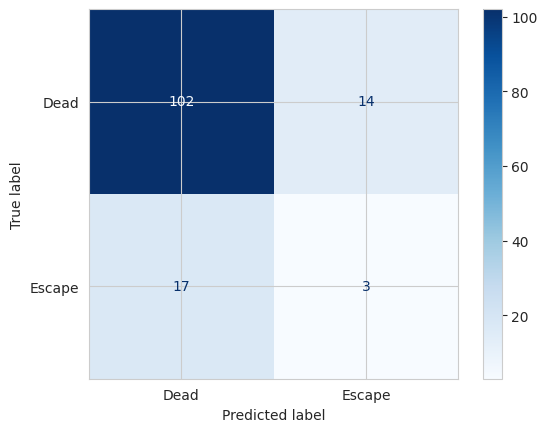

In [47]:
pred_knn = pipe_knn.predict(X_test)
cm4 = confusion_matrix(y_test, pred_knn)
ConfusionMatrixDisplay(cm4, display_labels = ['Dead', 'Escape']).plot(cmap = 'Blues')
tn, fp, fn, tp = cm4.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
print(accuracy)

The model had decent accuracy however it did not predict the escapes well so the model likely needs tuning in order to better predict whether the player will escape or not.

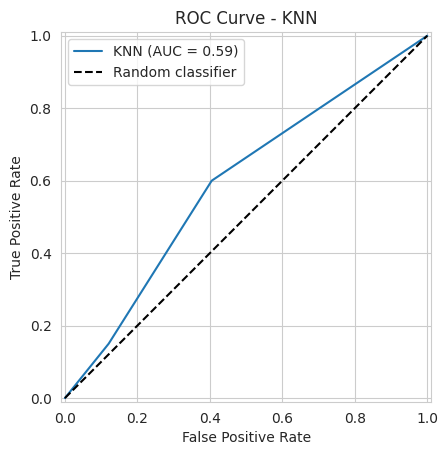

AUC Score: 0.5916


In [48]:
probs_knn = pipe_knn.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs_knn)
auc_score = roc_auc_score(y_test, probs_knn)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score, estimator_name='KNN').plot()
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.title('ROC Curve - KNN')
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

I did more model analysis with the AUC curve found that it had an AUC of 0.59, which shows that the model is slightly above average in predicting. However, it is still not the most robust at predicting whether the players will escape successfully or not.

In [49]:
print(classification_report(y_test, pred_knn, target_names=['Dead', 'Escape']))

              precision    recall  f1-score   support

        Dead       0.86      0.88      0.87       116
      Escape       0.18      0.15      0.16        20

    accuracy                           0.77       136
   macro avg       0.52      0.51      0.52       136
weighted avg       0.76      0.77      0.76       136



We looked at the classification report for the first model to see how the precision and recall of the escaped target looked. As expected, they both had low values of 0.18 and 0.15, showing that it is fairly successful at predicting the dead target. However, it cannot predict the escaped target consistently. The model threshold or the model number of clusters may be tuned in order to better predict this class.

In [50]:
param_grid_knn = {'model__n_neighbors': range(1, 31, 2)}
pipe_search = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring='roc_auc')
pipe_search.fit(X_train, y_train)
print(pipe_search.best_params_, pipe_search.best_score_)

probs = pipe_search.best_estimator_.predict_proba(X_test)[:, 1]
thresholds = [0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
results = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_test, preds)
    results.append({'Threshold': t, 'F1': f1})

results_df = pd.DataFrame(results)
print(results_df)

best_threshold = results_df.loc[results_df['F1'].idxmax(), 'Threshold']
print(f"Best threshold: {best_threshold}")

final_preds = (probs >= best_threshold).astype(int)
print(classification_report(y_test, final_preds, target_names=['Dead', 'Escape']))

{'model__n_neighbors': 15} 0.7040432152875175
   Threshold        F1
0       0.25  0.297872
1       0.30  0.333333
2       0.35  0.137931
3       0.40  0.137931
4       0.45  0.080000
5       0.50  0.095238
Best threshold: 0.3
              precision    recall  f1-score   support

        Dead       0.88      0.91      0.90       116
      Escape       0.38      0.30      0.33        20

    accuracy                           0.82       136
   macro avg       0.63      0.61      0.62       136
weighted avg       0.81      0.82      0.82       136



I decided to do a grid search on the KNN model to try to figure out which thresholds would be the best threshold for this unbalanced class of data and to figure out which number of clusters to use. We found the best threshold was 0.3 for a KNN, and the best number of clusters was 15. I decided to implement those below in the fifth model.

In [51]:
preprocess5 = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), cat_features),
    ('num', MinMaxScaler(), num_features)
])

pipe_knn_2 = Pipeline(steps = [
    ('prep', preprocess5),
    ('model', KNeighborsClassifier(n_neighbors=15))
])
pipe_knn_2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

Next I created the fifth model with the better parameters from the gridsearch and threshold testing. I implemented the new threshold below while evaluating the new model.

# Model 5 (Tuned kNN)

Accuracy at threshold 0.3: 0.8235
              precision    recall  f1-score   support

        Dead       0.88      0.91      0.90       116
      Escape       0.38      0.30      0.33        20

    accuracy                           0.82       136
   macro avg       0.63      0.61      0.62       136
weighted avg       0.81      0.82      0.82       136



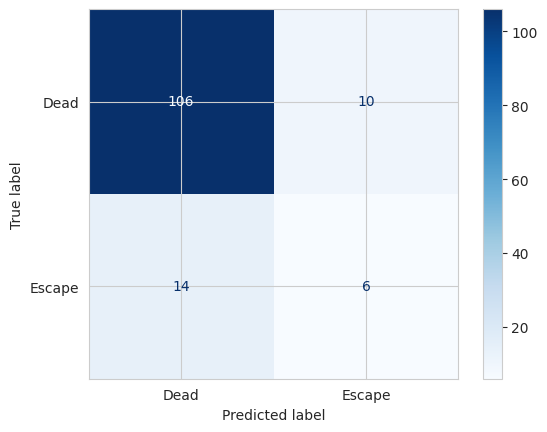

In [52]:
probs_knn_2 = pipe_knn_2.predict_proba(X_test)[:, 1]
threshold = .3
pred_knn_2 = (probs_knn_2 >= threshold).astype(int)
cm5 = confusion_matrix(y_test, pred_knn_2)
ConfusionMatrixDisplay(cm5, display_labels=['Dead', 'Escape']).plot(cmap='Blues')
tn_2, fp_2, fn_2, tp_2 = cm5.ravel()
accuracy_2 = (tp_2 + tn_2) / (tp_2 + tn_2 + fp_2 + fn_2)
print(f"Accuracy at threshold {threshold}: {accuracy_2:.4f}")
print(classification_report(y_test, pred_knn_2, target_names=['Dead', 'Escape']))

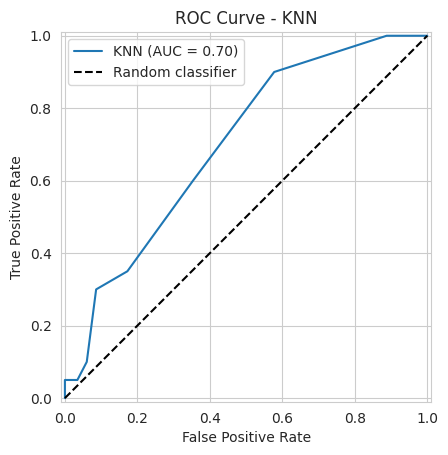

AUC Score: 0.6978


In [53]:

fpr_2, tpr_2, thresholds_2 = roc_curve(y_test, probs_knn_2)
auc_score_2 = roc_auc_score(y_test, probs_knn_2)
RocCurveDisplay(fpr=fpr_2, tpr=tpr_2, roc_auc=auc_score_2, estimator_name='KNN').plot()
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.title('ROC Curve - KNN')
plt.legend()
plt.show()

print(f"AUC Score: {auc_score_2:.4f}")

Created a classification report, Confusion Matrix, and ROC Curve to evaluate the performance the models witht the new adjustments. The changes to the threshold and number of neighbors increased the precisions and recall of the escape target however the model still struggles to predict this class. I believe that the other two model types used in this project perform better due to the balanced weight parameter. This is shown the low AUC score from the ROC curve showing that the Decision Tree and Logistic Regression are more effective classifiers of for this unbalanced data set.

Unlike logistic regression and decision trees, kNN can't use the balanced class weight argument, which puts it as a disadvantage due to the class imbalance of the target variable. Tuning the threshold helps a bit with this, but can't compensate for the discrepancy as much as the other models can, again putting it at a disadvantage.

# Conclusions

Our question was whether or not we can predict the result of a player's match based on the visible stats and information on the results screen of a match such as character played, the prestige level they are, and what item they bring, specifically in application to NightLight, a software that scrapes end screen data, but frequently loses the result field due to issues of cropping or other visual limitations.

Based on the results from our method section, the answer is yes but to a limited degree. The first 3 models returned ROC-AUC scores between 0.88 and 0.92 while the kNN models returned 0.59 and 0.70, suggesting the first 3 models could pretty reasonably distinguish between escapes and deaths. However, when looking at the confusion matrix for each model, it is evident that each model had a difficult time predicting escapes with corresponding f1 scores ranging from 0.26 to 0.60. Essentially, our models are good at accurately predicting when a player will die, but struggle when predicting an escape. Class imbalance was the most influential constraint, as before we tested any models, we found that the overall escape rate in the dataset was only 15%, meaning there was a large imbalance between deaths and escapes. We computed model 1 (Logistic Regression) with no adjustment for this, giving us a low escape recall of 0.15 as the model was basically defaulting to predict death every time. At the same time, we also had a high accuracy (0.88) and AUC score (0.9039), showing how evaluation metrics such as accuracy and AUC do not always accurately reflect the performance of the model. To address this we set "class_weight = balanced" and moved on to model 2 (Balanced Logistic Regression paired with Cross-Validation).

We also added/implemented cross-validation in the second model onward, which split our data into 5 folds and rotated through each fold for the validation/test set and using the remaining ones as the train set for the model. This gave us a more reliable and consistent idea of how our model performs on the dataset as well as detect any potential overfitting. Doing this largely improved the model's escape recall to 0.80 at the cost of slightly lower precision. The ROC-AUC curve improved from model 1 with a new value of 0.9155, reassuring that balancing the result class has improved the model.

A similar outcome was determined from our evaluations of model 3 (Decision Tree). We set the max_depth of the tree to 5 as not to have it grow too specifically on the training data, and later confirmed 4 or 5 as the best depth using Grid Search CV (partially due to the fact that it can't split beyond this point due to the size of the dataset). The results of this model were very similar to Model 2, with only slightly less precision values and a slightly higher escape recall value at the cost of a slightly lower dead recall value.

The kNN models (4 and 5), performed much worse, providing AUC scores of 0.59 and 0.70 respectively, even with tuning for the 5th model for threshold and k. This issue largely comes from the inability of kNN models to use the balanced class weights that the other models can use, which puts it at a disadvantage on this dataset which is very imbalanced in its target variable.

Overall our best performing model was model 2, producing the highest AUC (0.9155) as well as stable CV scores (AUC Mean: 0.8909 and AUC Standard Deviation: 0.0063) suggesting that this model generalizes the best and is not simply overfitting to the data. Regardless, all this goes to show that even after balancing the class weights, the models were still unable to reliably predict escapes at a high rate. Accuracy scores ranging from 83% to 88% are not bad, but can still be misleading metrics given the skewed data and sample size.

Another potential main factor in our results is the fact that outcomes of a Dead by Daylight match can be heavily influenced by things such as team-coordination, player behavior, and external factors that might affect player performance in a match. Therefore, while yes, looking at what a player brings into the match can be used to predict the match outcome, it may be better to consider how in-game decisions in combination with these factors affect the outcome. Taking a healthy balance between what a player is equipping/bringing as well as their in-game decisions is a good way to approach problems like this, but it's not always possible from certain perspectives like the NightLight software use-case, so we tried our best to make something that could predict the binary outcome using only the stats visible on the results screen, as that is what the software captures automatically when being run in the background.

# Team Contribution

Eli: Built decision tree model and drafted conclusion (~20% total)

Nathaniel: Data Engineer, Researcher, Built models 1 and 2, Reviewer (~50% total)

Max: Performed EDA and built kNN models (~30% total)